# Ambiguity perturbation — all type combinations

For every non-empty subset of
`lexical`, `syntactic`, `semantic`, `vagueness`, `incompleteness`, `referential`:

- **exists** — `True` if *any* type in the subset is present
- **sum** — how many types in the subset are present

Example for `{syntactic, vagueness, incompleteness}`:

- `ambiguity_exists_syntactic_vagueness_incompleteness`
- `ambiguity_sum_syntactic_vagueness_incompleteness`

Then correlate each derived metric with accuracy (as-is).


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import pearsonr, spearmanr


# accuracy

In [2]:
with open('../8.Accuracy/data.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

accuracy_data = {}
satisfaction_data = {}
has_code_location = {}
for nfr in data:
    nfr_id = nfr['id']
    llm_response = nfr['llm_response']
    gt_label = nfr['satisfaction_level'].lower()
    if gt_label == 'satisfied':
        gt = 4
    elif gt_label == 'weakly satisfied':
        gt = 3
    elif gt_label == 'weakly denied':
        gt = 2
    elif gt_label == 'denied':
        gt = 1
    else:
        raise Exception(nfr_id)
    accuracy_data[nfr_id] = 1 - abs(gt - llm_response) / 3
    satisfaction_data[nfr_id] = nfr['satisfaction_level']
    locs = nfr.get('code_location') or []
    has_code_location[nfr_id] = len(locs) > 0

# complexity

In [3]:
with open('../4.NFRComplexity/data.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

complexity_data = {}
for nfr in data:
    complexity_data[nfr['id']] = nfr['complexity']

# tracability

In [4]:
with open('../6.NFRTracability/data-tracability.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

locc_data = {}
cdc_data = {}
cdo_data = {}
docs_data = {}
docm_data = {}
for nfr in data:
    nfr_id = nfr['id']
    locc_data[nfr_id] = nfr['locc']
    cdc_data[nfr_id] = nfr['cdc']
    cdo_data[nfr_id] = nfr['cdo']
    docs_data[nfr_id] = nfr['docs']
    docm_data[nfr_id] = nfr['docm']

# ambiguity

In [5]:
with open('../14.ambiguity_again/second round/data_resolved.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

lexical_data = {}
syntactic_data = {}
semantic_data = {}
vagueness_data = {}
incompleteness_data = {}
referential_data = {}
ambiguity_exists_data = {}
sum_ambiguity_data = {}
sum_ambiguity_only_incomplete_and_vague_data = {}
ambiguity_only_incomplete_and_vague_exists_data = {}
for nfr in data:
    nfr_id = nfr['id']
    lexical_data[nfr_id] = nfr['Lexical']
    syntactic_data[nfr_id] = nfr['Syntactic']
    semantic_data[nfr_id] = nfr['Semantic']
    vagueness_data[nfr_id] = nfr['Vagueness']
    incompleteness_data[nfr_id] = nfr['Incompleteness']
    referential_data[nfr_id] = nfr['Referential']
    ambiguity_flags = [
        nfr['Lexical'], nfr['Syntactic'], nfr['Semantic'],
        nfr['Vagueness'], nfr['Incompleteness'], nfr['Referential'],
    ]
    ambiguity_exists_data[nfr_id] = any(ambiguity_flags)
    sum_ambiguity_data[nfr_id] = sum(ambiguity_flags)
    sum_ambiguity_only_incomplete_and_vague_data[nfr_id] = ambiguity_flags[3] + ambiguity_flags[4]
    ambiguity_only_incomplete_and_vague_exists_data[nfr_id] = sum_ambiguity_only_incomplete_and_vague_data[nfr_id] > 0

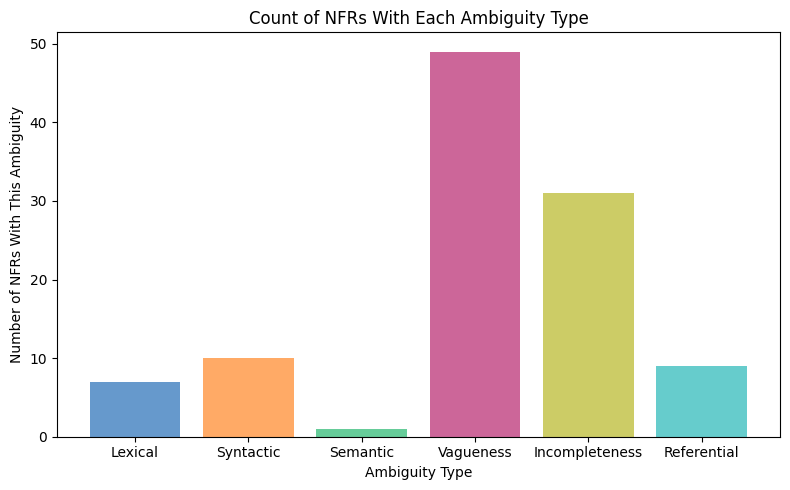

   Ambiguity Type  NFR Count
0         Lexical          7
1       Syntactic         10
2        Semantic          1
3       Vagueness         49
4  Incompleteness         31
5     Referential          9


In [6]:
import matplotlib.pyplot as plt

ambiguity_counts = {
    'Lexical': sum(lexical_data.values()),
    'Syntactic': sum(syntactic_data.values()),
    'Semantic': sum(semantic_data.values()),
    'Vagueness': sum(vagueness_data.values()),
    'Incompleteness': sum(incompleteness_data.values()),
    'Referential': sum(referential_data.values()),
}

plt.figure(figsize=(8, 5))
plt.bar(ambiguity_counts.keys(), ambiguity_counts.values(), color=['#6699cc', '#ffaa66', '#66cc99', '#cc6699', '#cccc66', '#66cccc'])
plt.xlabel('Ambiguity Type')
plt.ylabel('Number of NFRs With This Ambiguity')
plt.title('Count of NFRs With Each Ambiguity Type')
plt.tight_layout()
plt.show()

import pandas as pd
ambiguity_counts_df = pd.DataFrame(list(ambiguity_counts.items()), columns=['Ambiguity Type', 'NFR Count'])
print(ambiguity_counts_df)

# complexity2 metrics (`data_metrics.json`)

In [7]:
with open('../10.complexity2/data_metrics.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

# Collect all metric names; skip Entity Coherence (all null in this dataset)
complexity2_metric_names = list(data[0]['metrics'].keys())
complexity2_metric_names = [
    m for m in complexity2_metric_names
    if any(nfr['metrics'].get(m) is not None for nfr in data)
]

complexity2_data = {m: {} for m in complexity2_metric_names}
for nfr in data:
    nfr_id = nfr['id']
    for m in complexity2_metric_names:
        complexity2_data[m][nfr_id] = nfr['metrics'].get(m)

print(f'Loaded {len(complexity2_metric_names)} complexity2 metrics:')
for m in complexity2_metric_names:
    print(' -', m)

Loaded 11 complexity2 metrics:
 - Consensus grade level (Readability)
 - Headings count (Structure)
 - Headings per sentence (Structure)
 - List items count (Structure)
 - Lists per sentence (Structure)
 - SMAO sentences count (Requirements)
 - SMAO sentences % (Requirements)
 - Vague words per sentence (Requirements)
 - Anaphora per sentence (Requirements)
 - Sentence CV (Requirements)
 - CPRE terms per sentence (CPRE)


# combine all

In [8]:
df = pd.DataFrame({
    'accuracy': accuracy_data,
    'satisfaction': satisfaction_data,
    'has_code_location': has_code_location,
    'complexity': complexity_data,
    'locc': locc_data,
    'cdc': cdc_data,
    'cdo': cdo_data,
    'docs': docs_data,
    'docm': docm_data,
    'lexical': lexical_data,
    'syntactic': syntactic_data,
    'semantic': semantic_data,
    'vagueness': vagueness_data,
    'incompleteness': incompleteness_data,
    'referential': referential_data,
    'ambiguity_exists': ambiguity_exists_data,
    'sum_ambiguity': sum_ambiguity_data,
})
for m in complexity2_metric_names:
    df[m] = pd.Series(complexity2_data[m])

df.index.name = 'id'
df = df.reset_index()
df['is_denied'] = df['satisfaction'].str.lower() == 'denied'
df.head()

,id,accuracy,satisfaction,has_code_location,complexity,locc,cdc,cdo,docs,docm,...,Headings per sentence (Structure),List items count (Structure),Lists per sentence (Structure),SMAO sentences count (Requirements),SMAO sentences % (Requirements),Vague words per sentence (Requirements),Anaphora per sentence (Requirements),Sentence CV (Requirements),CPRE terms per sentence (CPRE),is_denied
0,1,1.000000,Satisfied,True,1,63,3,4,0.688587,0.627125,...,0.0,0,0.0,0,0.0,0.0,0.0,0.0,1.0,False
1,2,1.000000,Satisfied,True,0,23,5,5,0.879017,0.898760,...,0.0,0,0.0,0,0.0,0.0,0.0,0.0,1.0,False
2,3,1.000000,Satisfied,True,0,73,2,2,0.968287,0.962191,...,0.0,0,0.0,0,0.0,0.0,0.0,0.0,1.0,False
3,4,0.666667,Satisfied,True,0,15,1,2,0.000000,0.960000,...,0.0,0,0.0,0,0.0,0.0,0.0,0.0,1.0,False
4,5,0.666667,Weakly Denied,True,1,13,2,2,0.946746,0.946746,...,0.0,0,0.0,1,100.0,1.0,0.0,0.0,2.0,False


# Ambiguity combinations (exists + sum)


In [9]:
AMBIGUITY_TYPES = [
    'lexical', 'syntactic', 'semantic',
    'vagueness', 'incompleteness', 'referential',
]

combo_exists_cols = []
combo_sum_cols = []
combo_meta = []
new_cols = {}

for r in range(1, len(AMBIGUITY_TYPES) + 1):
    for combo in combinations(AMBIGUITY_TYPES, r):
        suffix = '_'.join(combo)
        exists_col = f'ambiguity_exists_{suffix}'
        sum_col = f'ambiguity_sum_{suffix}'
        flags = df[list(combo)].astype(bool)
        new_cols[exists_col] = flags.any(axis=1)
        new_cols[sum_col] = flags.sum(axis=1).astype(int)
        combo_exists_cols.append(exists_col)
        combo_sum_cols.append(sum_col)
        combo_meta.append({
            'types': '+'.join(combo),
            'k': r,
            'exists_col': exists_col,
            'sum_col': sum_col,
            'n_exists': int(new_cols[exists_col].sum()),
            'mean_sum': float(new_cols[sum_col].mean()),
        })

df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

combo_meta_df = pd.DataFrame(combo_meta)
print(f'Combinations: {len(combo_meta_df)} '
      f'({len(combo_exists_cols)} exists + {len(combo_sum_cols)} sum columns)')
combo_meta_df


Combinations: 63 (63 exists + 63 sum columns)


,types,k,exists_col,sum_col,n_exists,mean_sum
0,lexical,1,ambiguity_exists_lexical,ambiguity_sum_lexical,7,0.047297
1,syntactic,1,ambiguity_exists_syntactic,ambiguity_sum_syntactic,10,0.067568
2,semantic,1,ambiguity_exists_semantic,ambiguity_sum_semantic,1,0.006757
3,vagueness,1,ambiguity_exists_vagueness,ambiguity_sum_vagueness,49,0.331081
4,incompleteness,1,ambiguity_exists_incompleteness,ambiguity_sum_incompleteness,31,0.209459
...,...,...,...,...,...,...
58,lexical+syntactic+semantic+incompleteness+refe...,5,ambiguity_exists_lexical_syntactic_semantic_in...,ambiguity_sum_lexical_syntactic_semantic_incom...,49,0.391892
59,lexical+syntactic+vagueness+incompleteness+ref...,5,ambiguity_exists_lexical_syntactic_vagueness_i...,ambiguity_sum_lexical_syntactic_vagueness_inco...,86,0.716216
60,lexical+semantic+vagueness+incompleteness+refe...,5,ambiguity_exists_lexical_semantic_vagueness_in...,ambiguity_sum_lexical_semantic_vagueness_incom...,82,0.655405
61,syntactic+semantic+vagueness+incompleteness+re...,5,ambiguity_exists_syntactic_semantic_vagueness_...,ambiguity_sum_syntactic_semantic_vagueness_inc...,86,0.675676


# Correlations: ambiguity combination metrics vs accuracy


In [10]:
# All combination-derived metrics (exists + sum for every non-empty subset)
metrics = combo_exists_cols + combo_sum_cols

labels = {m: m for m in metrics}

MODE_NAME = 'as-is'

# accuracy distribution
acc = df['accuracy'].dropna()
print(f'=== {MODE_NAME} (n={len(acc)}) ===')
print(acc.value_counts(dropna=False).sort_index().to_string())
print(acc.describe().to_string())
print()


def subset_as_is(df, metric):
    return df[[metric, 'accuracy']].dropna()

def safe_corr(corr_fn, x, y):
    if len(x) < 2 or x.nunique() < 2 or y.nunique() < 2:
        return np.nan, np.nan
    r, p = corr_fn(x.astype(float), y.astype(float))
    return r, p

def fmt_corr(r, p):
    r_str = f'{r:.3f}' if pd.notna(r) else 'nan'
    p_str = f'{p:.3f}' if pd.notna(p) else 'nan'
    return r_str, p_str

summary_rows = []

for metric in metrics:
    valid = subset_as_is(df, metric)
    pr, pp = safe_corr(pearsonr, valid[metric], valid['accuracy'])
    sr, sp = safe_corr(spearmanr, valid[metric], valid['accuracy'])
    summary_rows.append({
        'metric': metric,
        'kind': 'exists' if metric.startswith('ambiguity_exists_') else 'sum',
        'types': metric.replace('ambiguity_exists_', '').replace('ambiguity_sum_', ''),
        'mode': MODE_NAME,
        'n': len(valid),
        'pearson_r': pr,
        'pearson_p': pp,
        'spearman_r': sr,
        'spearman_p': sp,
    })

summary = pd.DataFrame(summary_rows)
print(f'Computed correlations for {len(summary)} combination metrics')
summary.sort_values('pearson_p').head(20)


=== as-is (n=148) ===
accuracy
0.000000     4
0.333333    22
0.666667    55
1.000000    67
count    148.000000
mean       0.750000
std        0.269023
min        0.000000
25%        0.666667
50%        0.666667
75%        1.000000
max        1.000000

Computed correlations for 126 combination metrics


,metric,kind,types,mode,n,pearson_r,pearson_p,spearman_r,spearman_p
54,ambiguity_exists_syntactic_vagueness_incomplet...,exists,syntactic_vagueness_incompleteness_referential,as-is,148,-0.428986,5.329240e-08,-0.475607,1.004806e-09
61,ambiguity_exists_syntactic_semantic_vagueness_...,exists,syntactic_semantic_vagueness_incompleteness_re...,as-is,148,-0.417141,1.333734e-07,-0.462572,3.240410e-09
59,ambiguity_exists_lexical_syntactic_vagueness_i...,exists,lexical_syntactic_vagueness_incompleteness_ref...,as-is,148,-0.417141,1.333734e-07,-0.462572,3.240410e-09
34,ambiguity_exists_syntactic_vagueness_incomplet...,exists,syntactic_vagueness_incompleteness,as-is,148,-0.412222,1.932213e-07,-0.450428,9.237443e-09
62,ambiguity_exists_lexical_syntactic_semantic_va...,exists,lexical_syntactic_semantic_vagueness_incomplet...,as-is,148,-0.405322,3.218012e-07,-0.449568,9.933871e-09
44,ambiguity_exists_lexical_syntactic_vagueness_i...,exists,lexical_syntactic_vagueness_incompleteness,as-is,148,-0.399933,4.755524e-07,-0.436895,2.831681e-08
51,ambiguity_exists_syntactic_semantic_vagueness_...,exists,syntactic_semantic_vagueness_incompleteness,as-is,148,-0.399933,4.755524e-07,-0.436895,2.831681e-08
56,ambiguity_exists_lexical_syntactic_semantic_va...,exists,lexical_syntactic_semantic_vagueness_incomplet...,as-is,148,-0.387695,1.125627e-06,-0.423417,8.239025e-08
40,ambiguity_exists_vagueness_incompleteness_refe...,exists,vagueness_incompleteness_referential,as-is,148,-0.370838,3.488854e-06,-0.410185,2.248908e-07
50,ambiguity_exists_lexical_vagueness_incompleten...,exists,lexical_vagueness_incompleteness_referential,as-is,148,-0.358625,7.617424e-06,-0.396740,5.973965e-07


# Pearson / Spearman by combination


In [11]:
# Full correlation table for all combinations
corr_table = summary.set_index('metric')[
    ['kind', 'types', 'n', 'pearson_r', 'pearson_p', 'spearman_r', 'spearman_p']
].sort_values(['kind', 'types'])
corr_table.round(3)


,kind,types,n,pearson_r,pearson_p,spearman_r,spearman_p
metric,,,,,,,
ambiguity_exists_incompleteness,exists,incompleteness,148,-0.263,0.001,-0.282,0.001
ambiguity_exists_incompleteness_referential,exists,incompleteness_referential,148,-0.260,0.001,-0.286,0.000
ambiguity_exists_lexical,exists,lexical,148,-0.228,0.005,-0.222,0.007
ambiguity_exists_lexical_incompleteness,exists,lexical_incompleteness,148,-0.267,0.001,-0.284,0.000
ambiguity_exists_lexical_incompleteness_referential,exists,lexical_incompleteness_referential,148,-0.265,0.001,-0.289,0.000
...,...,...,...,...,...,...,...
ambiguity_sum_syntactic_vagueness_referential,sum,syntactic_vagueness_referential,148,-0.132,0.111,-0.194,0.018
ambiguity_sum_vagueness,sum,vagueness,148,-0.112,0.177,-0.124,0.134
ambiguity_sum_vagueness_incompleteness,sum,vagueness_incompleteness,148,-0.273,0.001,-0.342,0.000


# Exists vs sum side-by-side


In [12]:
exists_df = summary[summary['kind'] == 'exists'][
    ['types', 'pearson_r', 'pearson_p', 'spearman_r', 'spearman_p']
].rename(columns=lambda c: f'exists_{c}' if c != 'types' else c)

sum_df = summary[summary['kind'] == 'sum'][
    ['types', 'pearson_r', 'pearson_p', 'spearman_r', 'spearman_p']
].rename(columns=lambda c: f'sum_{c}' if c != 'types' else c)

side_by_side = exists_df.merge(sum_df, on='types', how='outer')
side_by_side = side_by_side.sort_values('exists_pearson_p')
side_by_side.round(3)


,types,exists_pearson_r,exists_pearson_p,exists_spearman_r,exists_spearman_p,sum_pearson_r,sum_pearson_p,sum_spearman_r,sum_spearman_p
57,syntactic_vagueness_incompleteness_referential,-0.429,0.000,-0.476,0.000,-0.272,0.001,-0.397,0.000
28,lexical_syntactic_vagueness_incompleteness_ref...,-0.417,0.000,-0.463,0.000,-0.322,0.000,-0.420,0.000
53,syntactic_semantic_vagueness_incompleteness_re...,-0.417,0.000,-0.463,0.000,-0.263,0.001,-0.385,0.000
56,syntactic_vagueness_incompleteness,-0.412,0.000,-0.450,0.000,-0.268,0.001,-0.374,0.000
24,lexical_syntactic_semantic_vagueness_incomplet...,-0.405,0.000,-0.450,0.000,-0.314,0.000,-0.409,0.000
...,...,...,...,...,...,...,...,...,...
50,syntactic_semantic_referential,-0.069,0.404,-0.091,0.272,-0.047,0.574,-0.088,0.290
43,syntactic,-0.050,0.545,-0.068,0.415,-0.050,0.545,-0.068,0.415
34,referential,-0.044,0.596,-0.056,0.497,-0.044,0.596,-0.056,0.497
47,syntactic_semantic,-0.024,0.772,-0.038,0.645,-0.024,0.772,-0.038,0.645


In [22]:
# Strongest |Pearson r| combinations (exists and sum separately)
cols = ['types', 'pearson_r', 'pearson_p', 'spearman_r', 'spearman_p', 'n']

print('=== exists (top 15 by |spearman_r|) ===')
display(
    summary[summary['kind'] == 'exists']
    .assign(abs_r=lambda d: d['spearman_r'].abs())
    .sort_values('abs_r', ascending=False)[cols]
    .head(3)
    .round(3)
)

print('=== sum (top 15 by |spearman_r|) ===')
display(
    summary[summary['kind'] == 'sum']
    .assign(abs_r=lambda d: d['spearman_r'].abs())
    .sort_values('abs_r', ascending=False)[cols]
    .head(3)
    .round(3)
)


=== exists (top 15 by |spearman_r|) ===


,types,pearson_r,pearson_p,spearman_r,spearman_p,n
54,syntactic_vagueness_incompleteness_referential,-0.429,0.0,-0.476,0.0,148
61,syntactic_semantic_vagueness_incompleteness_re...,-0.417,0.0,-0.463,0.0,148
59,lexical_syntactic_vagueness_incompleteness_ref...,-0.417,0.0,-0.463,0.0,148


=== sum (top 15 by |spearman_r|) ===


,types,pearson_r,pearson_p,spearman_r,spearman_p,n
122,lexical_syntactic_vagueness_incompleteness_ref...,-0.322,0.000,-0.420,0.0,148
125,lexical_syntactic_semantic_vagueness_incomplet...,-0.314,0.000,-0.409,0.0,148
117,syntactic_vagueness_incompleteness_referential,-0.272,0.001,-0.397,0.0,148


In [21]:
top = (
    summary[summary['kind'] == 'exists']
    .assign(abs_r=lambda d: d['spearman_r'].abs())
    .sort_values('abs_r', ascending=False)[cols]
    .head(3)
    .round(3)
)

for n in top['types']:
    print(n)

top = (
    summary[summary['kind'] == 'sum']
    .assign(abs_r=lambda d: d['spearman_r'].abs())
    .sort_values('abs_r', ascending=False)[cols]
    .head(3)
    .round(3)
)

for n in top['types']:
    print(n)

syntactic_vagueness_incompleteness_referential
syntactic_semantic_vagueness_incompleteness_referential
lexical_syntactic_vagueness_incompleteness_referential
lexical_syntactic_vagueness_incompleteness_referential
lexical_syntactic_semantic_vagueness_incompleteness_referential
syntactic_vagueness_incompleteness_referential


In [14]:
# Strongest |Spearman r| combinations (exists and sum separately)
cols = ['types', 'pearson_r', 'pearson_p', 'spearman_r', 'spearman_p', 'n']

print('=== exists (top 15 by |spearman_r|) ===')
display(
    summary[summary['kind'] == 'exists']
    .assign(abs_r=lambda d: d['spearman_r'].abs())
    .sort_values('abs_r', ascending=False)[cols]
    .head(15)
    .round(3)
)

print('=== sum (top 15 by |spearman_r|) ===')
display(
    summary[summary['kind'] == 'sum']
    .assign(abs_r=lambda d: d['spearman_r'].abs())
    .sort_values('abs_r', ascending=False)[cols]
    .head(15)
    .round(3)
)


=== exists (top 15 by |spearman_r|) ===


,types,pearson_r,pearson_p,spearman_r,spearman_p,n
54,syntactic_vagueness_incompleteness_referential,-0.429,0.0,-0.476,0.0,148
61,syntactic_semantic_vagueness_incompleteness_re...,-0.417,0.0,-0.463,0.0,148
59,lexical_syntactic_vagueness_incompleteness_ref...,-0.417,0.0,-0.463,0.0,148
34,syntactic_vagueness_incompleteness,-0.412,0.0,-0.450,0.0,148
62,lexical_syntactic_semantic_vagueness_incomplet...,-0.405,0.0,-0.450,0.0,148
51,syntactic_semantic_vagueness_incompleteness,-0.400,0.0,-0.437,0.0,148
44,lexical_syntactic_vagueness_incompleteness,-0.400,0.0,-0.437,0.0,148
56,lexical_syntactic_semantic_vagueness_incomplet...,-0.388,0.0,-0.423,0.0,148
40,vagueness_incompleteness_referential,-0.371,0.0,-0.410,0.0,148
55,semantic_vagueness_incompleteness_referential,-0.359,0.0,-0.397,0.0,148


=== sum (top 15 by |spearman_r|) ===


,types,pearson_r,pearson_p,spearman_r,spearman_p,n
122,lexical_syntactic_vagueness_incompleteness_ref...,-0.322,0.000,-0.420,0.0,148
125,lexical_syntactic_semantic_vagueness_incomplet...,-0.314,0.000,-0.409,0.0,148
117,syntactic_vagueness_incompleteness_referential,-0.272,0.001,-0.397,0.0,148
107,lexical_syntactic_vagueness_incompleteness,-0.317,0.000,-0.393,0.0,148
113,lexical_vagueness_incompleteness_referential,-0.328,0.000,-0.387,0.0,148
124,syntactic_semantic_vagueness_incompleteness_re...,-0.263,0.001,-0.385,0.0,148
119,lexical_syntactic_semantic_vagueness_incomplet...,-0.309,0.000,-0.381,0.0,148
123,lexical_semantic_vagueness_incompleteness_refe...,-0.319,0.000,-0.375,0.0,148
97,syntactic_vagueness_incompleteness,-0.268,0.001,-0.374,0.0,148
103,vagueness_incompleteness_referential,-0.278,0.001,-0.365,0.0,148


In [15]:
all_metrics_corr = summary.set_index('metric')[
    ['kind', 'types', 'pearson_r', 'pearson_p', 'spearman_r', 'spearman_p']
]
all_metrics_corr.round(3)


,kind,types,pearson_r,pearson_p,spearman_r,spearman_p
metric,,,,,,
ambiguity_exists_lexical,exists,lexical,-0.228,0.005,-0.222,0.007
ambiguity_exists_syntactic,exists,syntactic,-0.050,0.545,-0.068,0.415
ambiguity_exists_semantic,exists,semantic,0.077,0.353,0.085,0.306
ambiguity_exists_vagueness,exists,vagueness,-0.112,0.177,-0.124,0.134
ambiguity_exists_incompleteness,exists,incompleteness,-0.263,0.001,-0.282,0.001
...,...,...,...,...,...,...
ambiguity_sum_lexical_syntactic_semantic_incompleteness_referential,sum,lexical_syntactic_semantic_incompleteness_refe...,-0.282,0.001,-0.329,0.000
ambiguity_sum_lexical_syntactic_vagueness_incompleteness_referential,sum,lexical_syntactic_vagueness_incompleteness_ref...,-0.322,0.000,-0.420,0.000
ambiguity_sum_lexical_semantic_vagueness_incompleteness_referential,sum,lexical_semantic_vagueness_incompleteness_refe...,-0.319,0.000,-0.375,0.000


In [16]:
# Combinations with pearson_p or spearman_p < 0.06
significant = all_metrics_corr[
    (all_metrics_corr['pearson_p'] < 0.06) | (all_metrics_corr['spearman_p'] < 0.06)
].sort_values('pearson_p')
significant.round(3)


,kind,types,pearson_r,pearson_p,spearman_r,spearman_p
metric,,,,,,
ambiguity_exists_syntactic_vagueness_incompleteness_referential,exists,syntactic_vagueness_incompleteness_referential,-0.429,0.000,-0.476,0.000
ambiguity_exists_syntactic_semantic_vagueness_incompleteness_referential,exists,syntactic_semantic_vagueness_incompleteness_re...,-0.417,0.000,-0.463,0.000
ambiguity_exists_lexical_syntactic_vagueness_incompleteness_referential,exists,lexical_syntactic_vagueness_incompleteness_ref...,-0.417,0.000,-0.463,0.000
ambiguity_exists_syntactic_vagueness_incompleteness,exists,syntactic_vagueness_incompleteness,-0.412,0.000,-0.450,0.000
ambiguity_exists_lexical_syntactic_semantic_vagueness_incompleteness_referential,exists,lexical_syntactic_semantic_vagueness_incomplet...,-0.405,0.000,-0.450,0.000
...,...,...,...,...,...,...
ambiguity_exists_syntactic_vagueness,exists,syntactic_vagueness,-0.152,0.065,-0.170,0.039
ambiguity_exists_vagueness_referential,exists,vagueness_referential,-0.142,0.084,-0.162,0.050
ambiguity_sum_syntactic_vagueness_referential,sum,syntactic_vagueness_referential,-0.132,0.111,-0.194,0.018
